# Calibration measurement at the IP with needle

In [1]:
import os
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-backgrounds/06_analysis')

import numpy as _np
import matplotlib.pyplot as _plt
import pybdsim as _bd

from scipy.integrate import simpson
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

import beamNeedle

initializing ocelot...


### Date and save prefix

In [2]:
date = "2026_06_02"
save_name_prefix = "jupyter_notebooks/plots/EUXFEL/NeedleVM/" + date + "_EuXFEL_plot"

### Functions

In [3]:
def linear(x, a, b):
    return a * x + b

def gauss(x, a, sigma, mu):
    return a / (_np.sqrt(2 * _np.pi) * sigma) * _np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))


def needleX(x, c, R):
    return _np.piecewise(x, [x < -R, x > -R, x > R], [0, lambda xx: c*2*_np.sqrt(R**2 - xx**2), 0])


def needleY(y, c, R1, R2, length):
    y1 = 0
    y2 = length
    slope = (R2-R1)/(y2-y1)
    intercept = R1 - slope*y1
    surface = (R1 + 0.5*_np.abs(R2-R1))*_np.abs(y1-y2)
    return _np.piecewise(y, [y < y1, y > y1, y > y2], [0, lambda yy: c / surface * (slope * yy + intercept), 0])


def conv_needle_X(X, A=1, sigma=3e-5, mu=0, R=50e-6):
    x_gaus = gauss(X, 1, sigma, mu)
    x_needle = needleX(X, 1, R)

    conv = _np.convolve(x_gaus, x_needle, "same")
    conv = conv / simpson(conv, X)

    func = interp1d(X, conv, fill_value='extrapolate')
    return A * func(X)


def conv_needle_Y(Y, A=1, sigma=3e-5, mu=0, R1=50e-6, R2=200e-6, length=10e-3):
    y_gaus = gauss(Y, 1, sigma, mu)
    y_needle = needleY(Y, 1, R1, R2, length)

    conv = _np.convolve(y_gaus, y_needle, "same")
    conv = conv / simpson(conv, Y)

    func = interp1d(Y, conv, fill_value='extrapolate')
    return A * func(Y)

In [4]:
def plotConvolutionX(a=1, sigma=10e-6, mu=0, c=1, R=50e-6, A=1, xmin=-1e-3, xmax=1e-3):
    X = _np.linspace(xmin, xmax, 500)
    _plt.plot(X, gauss(X, a, sigma, mu), '--', label=r"$g_{\rm beam}$")
    _plt.plot(X, needleX(X, c, R), '--', label=r"$p_{\rm needle}$")
    _plt.plot(X, conv_needle_X(X, A, sigma, mu, R), ls='-', label=r"$g_{\rm beam}\otimes p_{\rm needle}$")
    _plt.legend()
    _plt.ticklabel_format(style='sci', axis='y', scilimits=(1, 1))
    _plt.ticklabel_format(style='sci', axis='x', scilimits=(-3, -3))
    _plt.ylabel(r"Intensity")
    _plt.xlabel(r"$x$")
    

def plotConvolutionY(a=1, sigma=10e-6, mu=0, c=1, R1=20e-6, R2=200e-6, length=10e-3, A=1, xmin=4e-3, xmax=6e-3):
    Y = _np.append(-_np.logspace(-3, -7, 100), _np.logspace(-7, -3, 100))
    _plt.plot(Y, gauss(Y, a, sigma, mu), '--', label=r"$g_{\rm beam}$")
    _plt.plot(Y, needleY(Y, c, R1, R2, length), '--', label=r"$p_{\rm needle}$")
    _plt.plot(Y, conv_needle_Y(Y, A, sigma, mu, R1, R2, length), ls='-', label=r"$g_{\rm beam}\otimes p_{\rm needle}$")
    _plt.legend()
    _plt.ticklabel_format(style='sci', axis='y', scilimits=(1, 1))
    _plt.ticklabel_format(style='sci', axis='x', scilimits=(-3, -3))
    _plt.xlabel(r"$y$")

## Convolutions

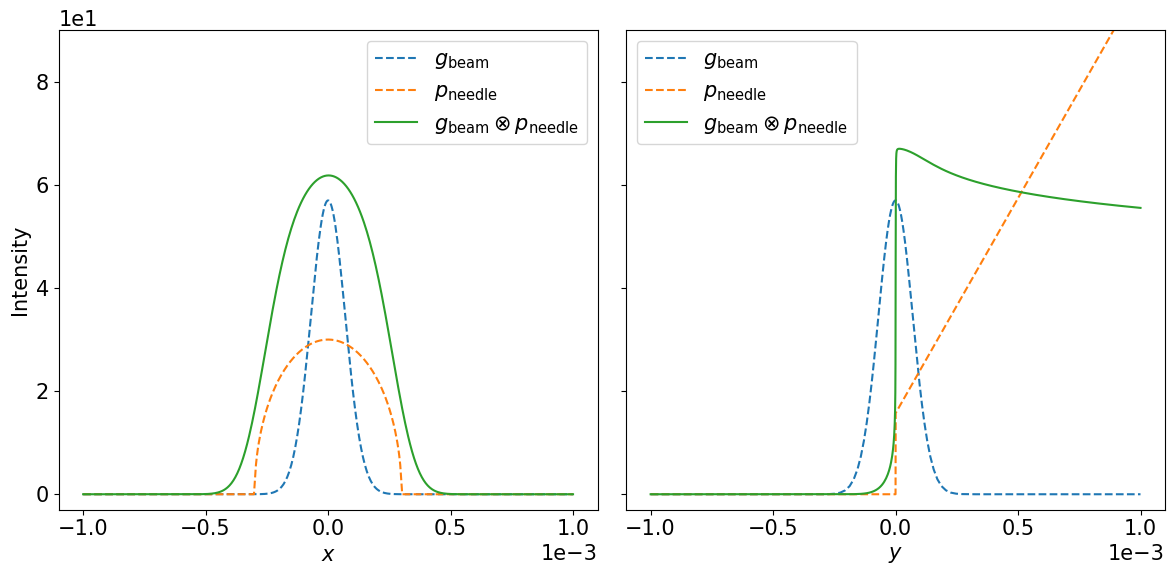

In [5]:
_plt.rcParams['font.size']=15
_plt.subplots(1, 2, sharey=True, figsize=[12, 6])
_plt.subplot(121)
plotConvolutionX(a=1e-2, sigma=70e-6, mu=0, c=5e4, R=300e-6, A=3e-2)
_plt.ylim(-0.3e1, 9e1)
_plt.subplot(122)
plotConvolutionY(a=1e-2, c=3e-1, A=6e-2, sigma=70e-6, R1=7e-6, R2=100e-6, length=2.5e-3, xmin=-1e-3, xmax=1e-3)
_plt.tight_layout()
_plt.savefig("{}_Convolution_needle_XY.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

## X scan data

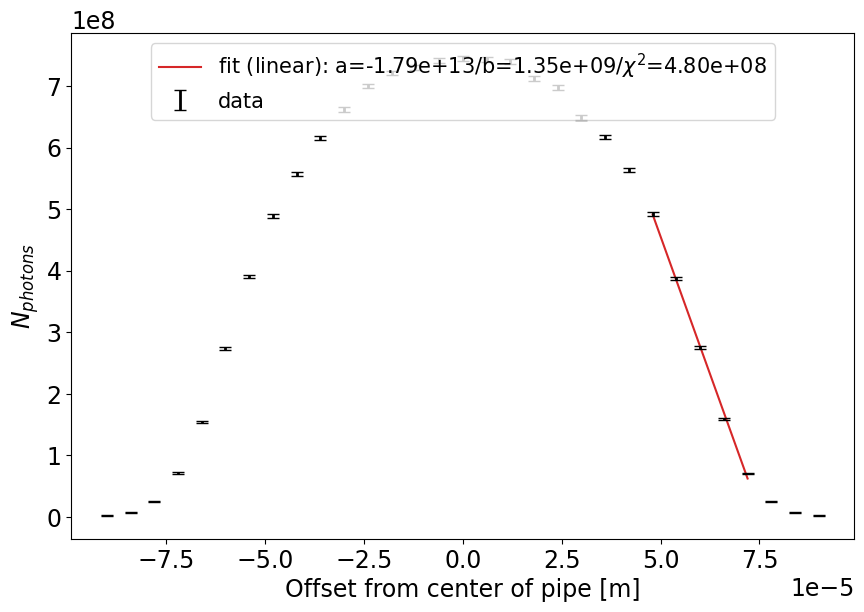

In [6]:
beamNeedle.PlotIntegralNeedle('root_files/beamNeedle/T20_needle_*Y_+0.00e-3_merged_hist.root', 'PHOTONS_E', 'X', 
                              a=None, sigmax=10e-6, sigmay=10e-6, mux=0, muy=0, b=None, length=1e-3, R1=7e-6, R2=125e-6,
                              manualFit=False, autoFit=False, autoFitFixed=False, linFit=True, fitRange=[4.5e-5, 7.5e-5])

## Y scan data

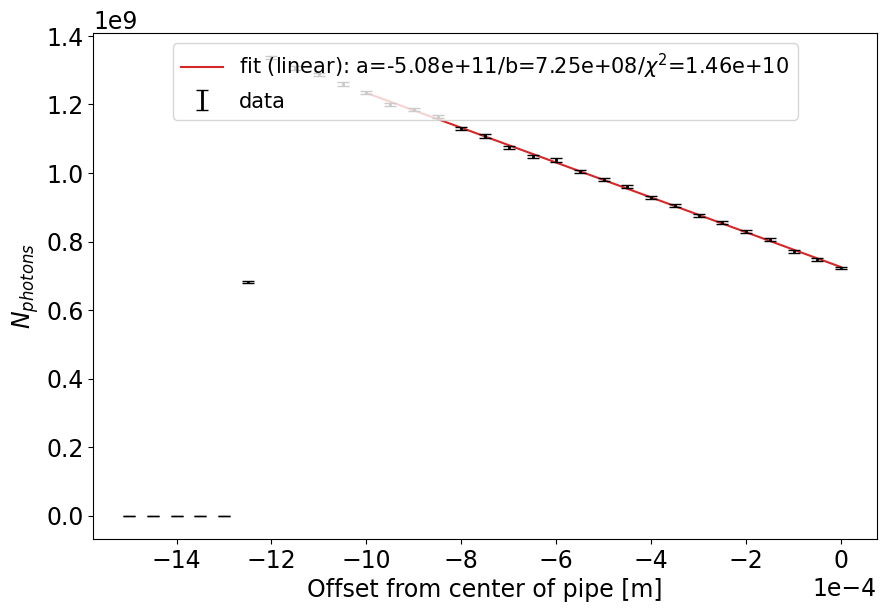

In [7]:
beamNeedle.PlotIntegralNeedle('root_files/beamNeedle/T20_needle_X_+0.00e-5*_merged_hist.root', 'PHOTONS_R', 'Y', 
                              a=None, sigmax=10e-6, sigmay=10e-6, mux=0, muy=0, b=None, length=1e-3, R1=7e-6, R2=125e-6,
                              manualFit=False, autoFit=False, autoFitFixed=False, linFit=True, fitRange=[-1e-3, 0])
_plt.ticklabel_format(axis='x', style='sci', scilimits=(-4,-4))

## Reconstruction X

In [32]:
fitRange=[4.5e-5, 7.5e-5]
OFFSETS, NPHOTONS, ERRORS = beamNeedle.countPhotonsInHistAllFiles('root_files/beamNeedle/T20_needle_*Y_+0.00e-3_merged_hist.root', 
                                                                  'PHOTONS_E', 'X')
OFFSETS_cut = _np.array(OFFSETS[[fitRange[0] <= offset <= fitRange[1] for offset in OFFSETS]])
NPHOTONS_cut = _np.array(NPHOTONS[[fitRange[0] <= offset <= fitRange[1] for offset in OFFSETS]])
popt, pcov = curve_fit(linear, OFFSETS_cut, NPHOTONS_cut, p0=[max(NPHOTONS)/3, max(NPHOTONS)/3])

In [33]:
a, b = popt
sigma_a = _np.sqrt(pcov[0, 0])
sigma_b = _np.sqrt(pcov[1, 1])
cov_ab  = pcov[0, 1]

In [34]:
x_needle = 60e-6
x = (NPHOTONS_cut - b) / a
sigma_x = _np.sqrt(x**2 * sigma_a**2 + sigma_b**2 + 2*x*cov_ab) / abs(a)

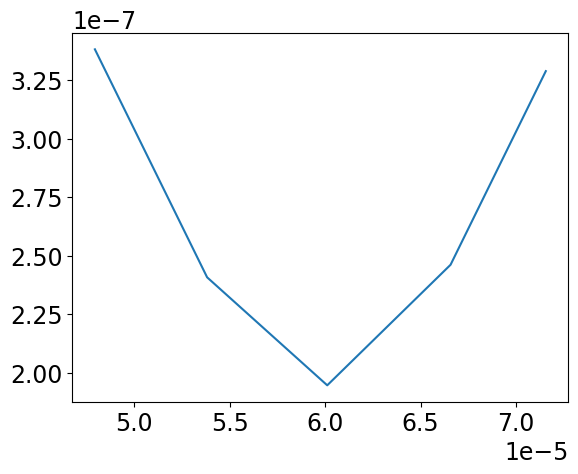

In [35]:
_plt.plot(x, sigma_x)

In [11]:
TrackingVect = _np.random.normal(0, 5e-6, size=1_000_000)
GaussSpread = _np.random.normal(0, _np.mean(sigma_x), len(TrackingVect))
MeasVect = TrackingVect + GaussSpread

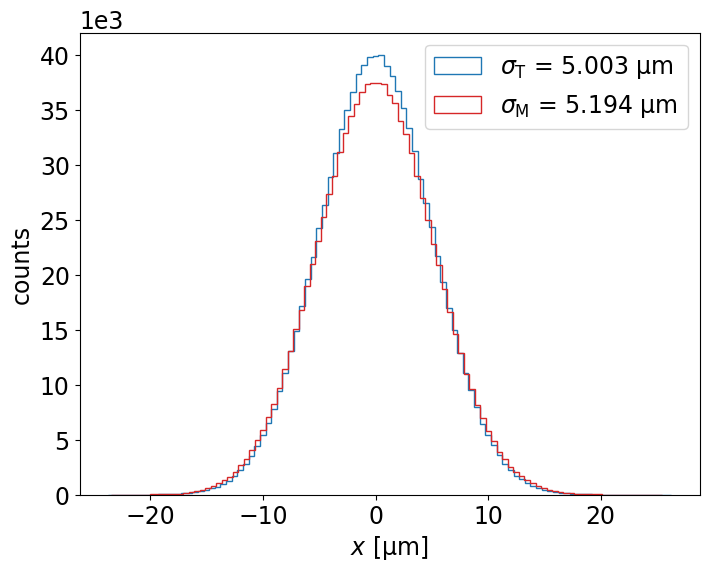

In [12]:
_plt.figure(figsize=[8, 6])
T = TrackingVect*1e6
M = MeasVect*1e6
_plt.hist(T, bins=100, histtype='step', color='C0', label=r"$\sigma_{{\rm T}}$ = {:.3f} $\rm \mu m$".format(_np.std(T)))
_plt.hist(M, bins=100, histtype='step', color='C3', label=r"$\sigma_{{\rm M}}$ = {:.3f} $\rm \mu m$".format(_np.std(M)))
_plt.ticklabel_format(style='sci', axis='y', scilimits=(3, 3))
_plt.ylabel(r"counts")
_plt.xlabel(r"$x$ [$\rm\mu$m]")
_plt.legend()
_plt.savefig("{}_Example_measurment_5um.pdf".format(save_name_prefix), dpi=300, bbox_inches='tight')

In [13]:
ResVect = (MeasVect-TrackingVect)*1e6

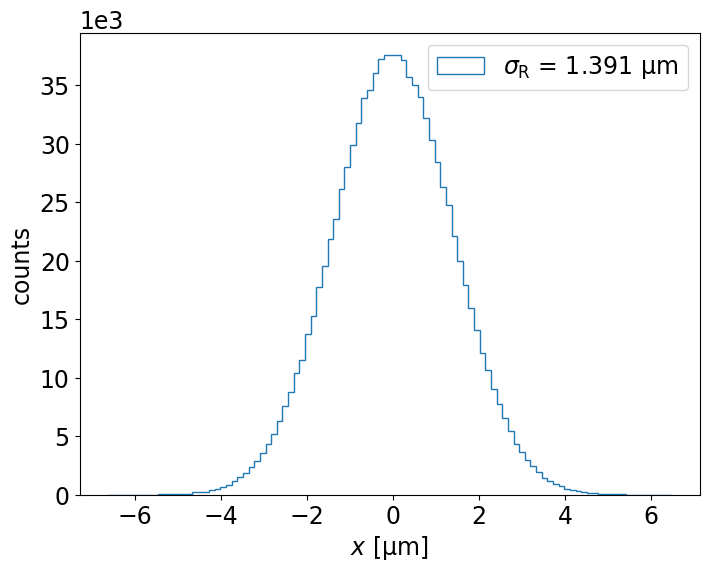

In [14]:
_plt.figure(figsize=[8, 6])
_plt.hist(ResVect, bins=100, histtype='step', color='C0', label=r"$\sigma_{{\rm R}}$ = {:.3f} $\rm \mu m$".format(_np.std(ResVect)))
_plt.ticklabel_format(style='sci', axis='y', scilimits=(3, 3))
_plt.ylabel(r"counts")
_plt.xlabel(r"$x$ [$\rm\mu$m]")
_plt.legend()

## Reconstruction Y

In [15]:
fitRange=[-1e-3, 0]
OFFSETS, NPHOTONS, ERRORS = beamNeedle.countPhotonsInHistAllFiles('root_files/beamNeedle/T20_needle_X_+0.00e-5*_merged_hist.root', 
                                                                  'PHOTONS_R', 'Y')
OFFSETS_cut = _np.array(OFFSETS[[fitRange[0] <= offset <= fitRange[1] for offset in OFFSETS]])
NPHOTONS_cut = _np.array(NPHOTONS[[fitRange[0] <= offset <= fitRange[1] for offset in OFFSETS]])
popt, pcov = curve_fit(linear, OFFSETS_cut, NPHOTONS_cut, p0=[max(NPHOTONS)/3, max(NPHOTONS)/3])

In [16]:
a, b = popt
sigma_a = _np.sqrt(pcov[0, 0])
sigma_b = _np.sqrt(pcov[1, 1])
cov_ab  = pcov[0, 1]

In [17]:
print("{:.2e}".format(a),"{:.2e}".format(b),"{:.2e}".format(cov_ab),"{:.2e}".format(sigma_a),"{:.2e}".format(sigma_b))

-5.08e+11 7.25e+08 5.71e+15 3.38e+09 1.98e+06


In [27]:
y_needle = 5e-4
y = (NPHOTONS_cut - b) / a
sigma_y = _np.sqrt(y**2 * sigma_a**2 + sigma_b**2 + 2*y*cov_ab) / abs(a)

In [28]:
sigma_y

array([3.90900875e-06, 3.52069079e-06, 3.36210334e-06, 3.14714044e-06,
       2.82037793e-06, 2.62221961e-06, 2.35948451e-06, 2.21075856e-06,
       2.15521421e-06, 2.03978199e-06, 2.01451070e-06, 2.03002005e-06,
       2.12212378e-06, 2.24033297e-06, 2.42698330e-06, 2.58648155e-06,
       2.82243773e-06, 3.02635488e-06, 3.38800182e-06, 3.64397389e-06,
       3.92124575e-06])

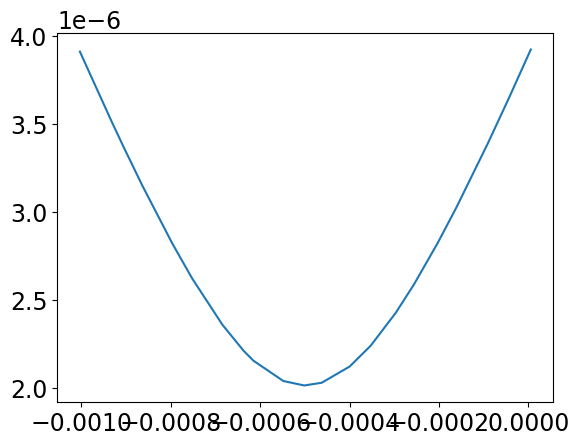

In [29]:
_plt.plot(y, sigma_y)

In [20]:
_np.mean(sigma_y)

np.float64(4.0823043762653725e-06)

In [21]:
TrackingVect = _np.random.normal(0, 5e-6, size=1_000_000)
GaussSpread = _np.random.normal(0, _np.mean(sigma_x), len(TrackingVect))
MeasVect = TrackingVect + GaussSpread

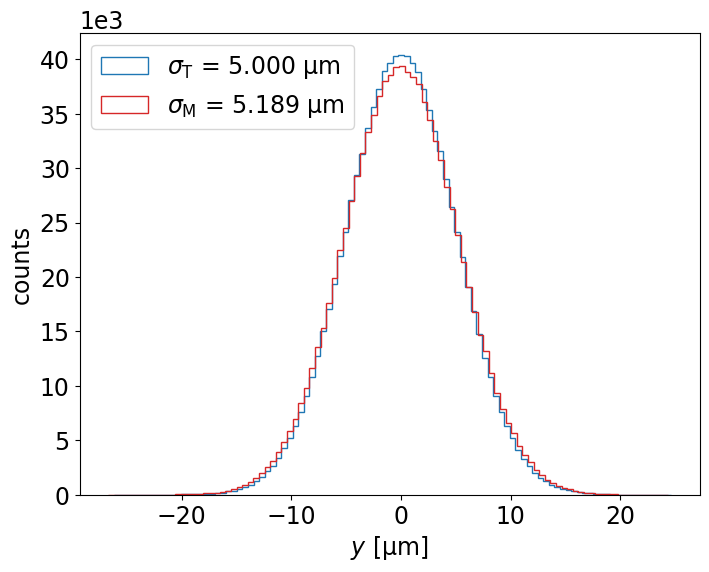

In [22]:
_plt.figure(figsize=[8, 6])
T = TrackingVect*1e6
M = MeasVect*1e6
_plt.hist(T, bins=100, histtype='step', color='C0', label=r"$\sigma_{{\rm T}}$ = {:.3f} $\rm \mu m$".format(_np.std(T)))
_plt.hist(M, bins=100, histtype='step', color='C3', label=r"$\sigma_{{\rm M}}$ = {:.3f} $\rm \mu m$".format(_np.std(M)))
_plt.ticklabel_format(style='sci', axis='y', scilimits=(3, 3))
_plt.ylabel(r"counts")
_plt.xlabel(r"$y$ [$\rm\mu$m]")
_plt.legend()

In [23]:
ResVect = (MeasVect-TrackingVect)*1e6

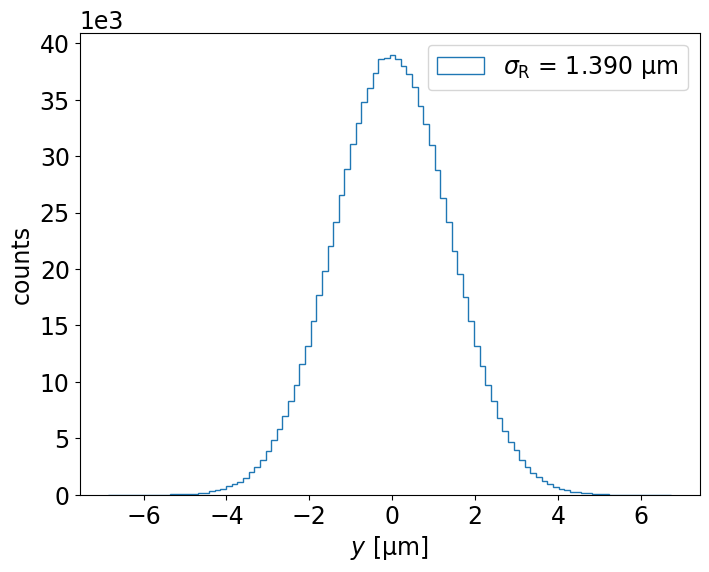

In [24]:
_plt.figure(figsize=[8, 6])
_plt.hist(ResVect, bins=100, histtype='step', color='C0', label=r"$\sigma_{{\rm R}}$ = {:.3f} $\rm \mu m$".format(_np.std(ResVect)))
_plt.ticklabel_format(style='sci', axis='y', scilimits=(3, 3))
_plt.ylabel(r"counts")
_plt.xlabel(r"$y$ [$\rm\mu$m]")
_plt.legend()